In [8]:
1+1 

2

In [9]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import torch
import torchaudio
from IPython import display
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
import soundfile as sf
import wandb
%matplotlib inline
import os 

In [10]:
classes = ["Electronic", "Experimental", "Folk", "Hip-Hop", "Instrumental", "International", "Rock"]

In [11]:
class AudioDataset(Dataset):
    def __init__(
        self,
        path_to_csv: str,
        path_to_folder: str,
        pad_size: int = 1323000,
        sr: int = 44100,
    ):
        self.csv: pd.DataFrame = pd.read_csv(path_to_csv)[["track_id", "genre"]]
        self.path_to_folder = path_to_folder
        self.pad_size = pad_size

        self.sr = sr

        self.class_to_idx = {classes[i]: i for i in range(7)}

    def __getitem__(self, index: int):
        row = self.csv.iloc[index]

        file_id = str(row["track_id"])
        if not file_id.endswith(".wav"):
            file_id += ".wav"

        path = os.path.join(self.path_to_folder, file_id)

        x, sr = sf.read(path)
        x = torch.tensor(x, dtype=torch.float32)
        
        if x.ndim == 2:
            x = x.mean(dim=1)
            
        if sr != self.sr:
            x = torchaudio.functional.resample(x, sr, self.sr)

        real_len = x.shape[0]

        if real_len < self.pad_size:
            pad_len = self.pad_size - real_len
            x = torch.nn.functional.pad(x, (0, pad_len))
        else:
            x = x[:self.pad_size]
            real_len = self.pad_size

        y = int(row["genre"])

        return {"x": x, "y": y, "len": real_len}

    def __len__(self):
        return self.csv.shape[0]

In [12]:
BASE_DIR = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))

duration = 30

padsize =  int(1323000 / 30 * duration)

train_dataset = AudioDataset(
    os.path.join(BASE_DIR, "data_csv", "train_meta_nopop.csv"),
    os.path.join(BASE_DIR, "data", "audio_train"), pad_size=padsize
)
val_dataset = AudioDataset(
    os.path.join(BASE_DIR, "data_csv", "val_meta_nopop.csv"),
    os.path.join(BASE_DIR, "data", "audio_val"), pad_size=padsize
)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

In [13]:
def train_audio_clfr(
    model,
    optimizer,
    train_dataloader,
    sr,
    criterion=torch.nn.CrossEntropyLoss(),
    data_transform=None,
    augmentation=None,
    num_epochs=10,
    device="cuda",
    verbose_num_iters=10,
):
    model.train()
    iter_i = 0

    train_losses = []
    train_accuracies = []

    for epoch in range(num_epochs):
        epoch_losses = []
        epoch_accs = []

        for batch in train_dataloader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            lens = batch["len"].to(device)

            # применяем преобразование входных данных
            if data_transform:
                x, lens = data_transform(x, lens, device=device, sr=sr)

            # примеменяем к логмелспектрограмме аугментацию
            if augmentation:
                x, lens = augmentation(x, lens)

            probs = model(x, lens)
            optimizer.zero_grad()
            loss = criterion(probs, y)
            loss.backward()
            optimizer.step()

            loss_val = loss.item()
            train_losses.append(loss_val)
            epoch_losses.append(loss_val)

            # считаем точность предсказания
            pred_cls = probs.argmax(dim=-1)
            acc_val = (pred_cls == y).float().mean().item()
            train_accuracies.append(acc_val)
            epoch_accs.append(acc_val)

            
            wandb.log({"train/loss": loss_val, "train/accuracy": acc_val}, step=iter_i)

            iter_i += 1

            # раз в verbose_num_iters визуализируем наши лоссы и семплы
            if iter_i % verbose_num_iters == 0:
                clear_output(wait=True)

                print(f"Epoch {epoch}")

                plt.figure(figsize=(10, 5))

                plt.subplot(1, 2, 1)
                plt.xlabel("Iteration")
                plt.ylabel("Train loss")
                plt.plot(np.arange(iter_i), train_losses)

                plt.subplot(1, 2, 2)
                plt.xlabel("Iteration")
                plt.ylabel("Train acc")
                plt.plot(np.arange(iter_i), train_accuracies)

                plt.show()

        
        wandb.log({
            "epoch": epoch,
            "epoch/train_loss": np.mean(epoch_losses),
            "epoch/train_accuracy": np.mean(epoch_accs),
        }, step=iter_i)

    model.eval()

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
def plot_confusion_matrix(model, val_dataloader, sr, device, data_transform=None):
    pred_true_pairs = []
    for batch in val_dataloader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        lens = batch["len"].to(device)

        with torch.no_grad():
            if data_transform:
                x, lens = data_transform(x, lens, sr=sr, device=device)

            probs = model(x, lens)

            pred_cls = probs.argmax(dim=-1)

        for pred, true in zip(pred_cls.cpu().detach().numpy(), y.cpu().numpy()):
            pred_true_pairs.append((pred, true))

    val_acc = np.mean([p[0] == p[1] for p in pred_true_pairs])
    print(f"Val accuracy: {val_acc}")

    wandb.log({"val/accuracy": val_acc})

    cm_df = pd.DataFrame(
        confusion_matrix(
            [p[1] for p in pred_true_pairs],
            [p[0] for p in pred_true_pairs],
            normalize="true",
        ),
        columns=classes,
        index=classes,
    )
    sn.heatmap(cm_df, annot=True)

In [16]:
def compute_log_melspectrogram(wav_batch, lens, sr, device="cpu"):
    n_fft = 1024
    win_length = 1024
    hop_length = 256
    n_mels = 64

    wav_batch = wav_batch.to(device)

    windows = wav_batch.unfold(dimension=1, size=win_length, step=hop_length)
    filter = torch.hann_window(win_length, device=device)
    windows_with_applied_filter = windows * filter[None, None, :]

    fft_features = torch.fft.fft(windows_with_applied_filter, n=n_fft, dim=-1)[:, :, : n_fft // 2 + 1]

    fft_magnitudes = torch.abs(fft_features ** 2)

    melscale = torchaudio.transforms.MelScale(n_mels=n_mels, sample_rate=sr, n_stft=n_fft // 2 + 1).to(device)

    mel_spectrogram = melscale(fft_magnitudes.transpose(1, 2))

    logmel_spectrogram = torch.log(mel_spectrogram.clamp(1e-5))

    return logmel_spectrogram, lens // hop_length

Пробуем улучшенную архитектуру для флагманской модели

In [17]:
class CNN10(nn.Module):
    def __init__(self, num_classes=7, hidden=12):
        super().__init__()

        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(1, hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.GELU(),
            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(hidden, hidden * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 2),
            nn.GELU(),
            nn.Conv2d(hidden * 2, hidden * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 2),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.1),

            nn.Conv2d(hidden * 2, hidden * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 4),
            nn.GELU(),
            nn.Conv2d(hidden * 4, hidden * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 4),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.15),
        )

        self.final_mlp = nn.Sequential(
            nn.Linear(hidden * 4, 128),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes),
        )

    def forward(self, x, lens):
        z = self.cnn_backbone(x[:, None, :, :])
        z = torch.nn.functional.max_pool2d(z, kernel_size=z.size()[2:])[:, :, 0, 0]
        return self.final_mlp(z)

In [18]:
cnn = CNN10()
cnn.to(device)

optim = torch.optim.AdamW(cnn.parameters(), lr=3e-4)



In [19]:
wandb.init(
    project="gp5-audio-classification",
    name="CNN10_8-30_pop_removed_v2",
    config={
        "model": "CNN10_v2",
        "optimizer": "AdamW",
        "lr": 3e-4,
        "num_epochs": 10,
        "batch_size": 32,
    },
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\tim7m\_netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch 9


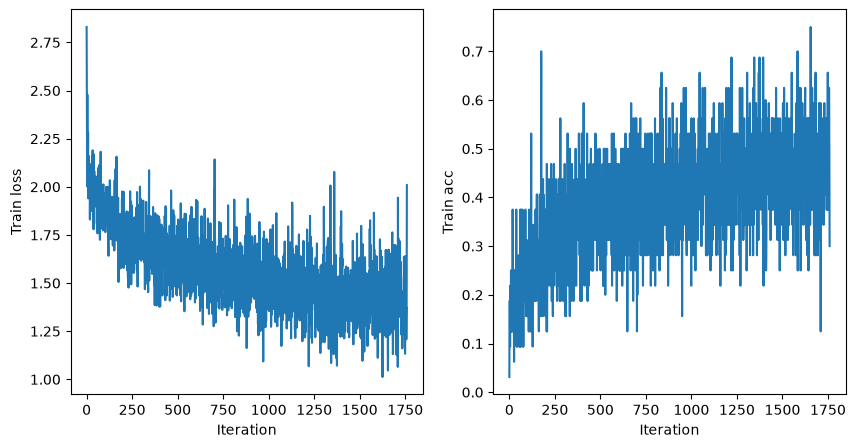

In [20]:
train_audio_clfr(
    cnn,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
)


In [21]:
# сохраняем модель как артефакт wandb
torch.save(cnn.state_dict(), "cnn10v2.pth")
artifact = wandb.Artifact("cnn10v2_model", type="model")
artifact.add_file("cnn10v2.pth")
wandb.log_artifact(artifact)

<Artifact cnn10v2_model>

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Val accuracy: 0.5486661860129777


epoch,▁▂▃▃▄▅▆▆▇█
epoch/train_accuracy,▁▄▅▆▆▇▇███
epoch/train_loss,█▅▄▃▃▂▂▁▁▁
train/accuracy,▁▂▁▄▁▃▃▅▄▂▆▄▇▆▅▅▇▅▅▅█▅▅▆██▅▅▃█▅▅▅▅▆▃▄▅▇▆
train/loss,█▅▅▅▃▄▄▄▂▅▄▃▃▃▅▄▄▃▅▃▄▃▂▃▅▃▂▂▄▂▂▄▃▂▂▃▃▁▂▁
val/accuracy,▁
epoch,9
epoch/train_accuracy,0.46229
epoch/train_loss,1.41925
train/accuracy,0.3
train/loss,2.00879


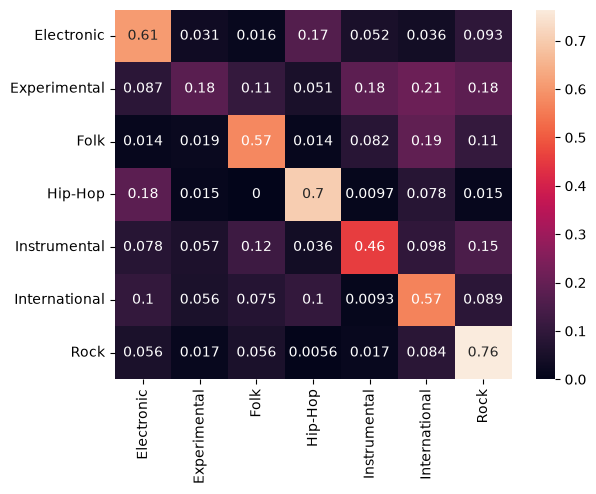

In [22]:
plot_confusion_matrix(
    cnn,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)
wandb.finish()